# How Many Stocks \U0001F522
### "Twenty is enough" is the right answer to the wrong question.

![Signal: Confirmed](https://img.shields.io/badge/Signal-Confirmed-2ea44f?style=flat-square)
![Tradability: Useful](https://img.shields.io/badge/Tradability-Useful-2ea44f?style=flat-square)

Every textbook has the chart: portfolio risk against number of holdings, dropping steeply then
flattening out around fifteen or twenty names. The chart is accurate. But it plots the risk of
the *average* portfolio, and you will only ever own **one**.

> \U0001F4D3 **This is the plain-language layer.** The three curves, the skew mechanism and the
> two-knob identification test are in **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice.** Every chart below is generated by the code beside it.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../.."))   # repo root (quantlab/ lives there)
sys.path.insert(0, os.path.abspath(".."))          # the study package
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

## The answer first \U0001F3AF

| Question | Answer |
|---|---|
| Does the textbook curve flatten around 15-20? | Yes. |
| Is that the risk you care about? | No. |
| How many to narrow the range of *outcomes*? | Roughly twice as many. |
| Why the difference? | A few stocks carry everything. |

## 1 · The chart from the textbook

In [2]:
from howmany import data, strategy as st

px = data.load_prices()
R = st.usable_panel(px, data.NAMES)
Rc = R.dropna()
print(f"as-of {data.AS_OF} | {R.shape[1]} names, {len(Rc):,} common sessions "
      f"from {Rc.index[0].date()} ({len(Rc)/252:.1f} years)")
print("Every name here is still listed in 2026 -- a selection nobody could have made")
print("at the start. It inflates the LEVEL of every curve; the SHAPE is the subject.")

as-of 2026-06-30 | 40 names, 4,146 common sessions from 2010-01-05 (16.5 years)
Every name here is still listed in 2026 -- a selection nobody could have made
at the start. It inflates the LEVEL of every curve; the SHAPE is the subject.


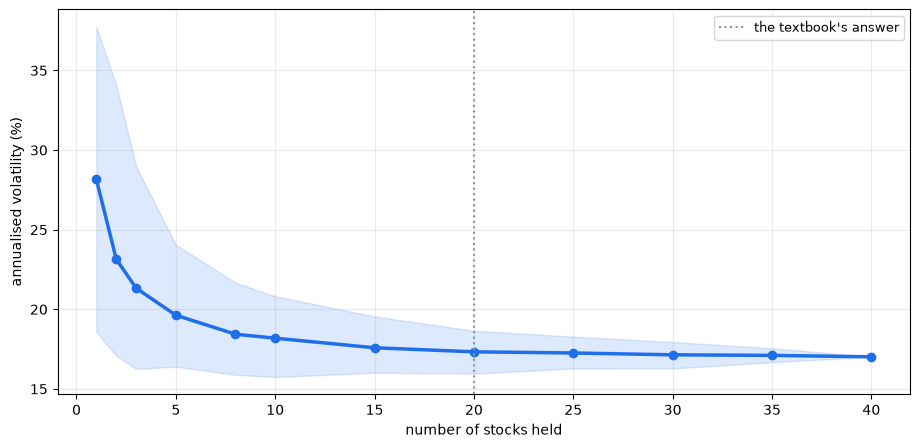

90% of the achievable reduction: 10 stocks


In [3]:
vc = st.volatility_curve(R, n_draws=400)
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(vc.index, vc["mean_vol"] * 100, "o-", lw=2.5, color="#1f6feb")
ax.fill_between(vc.index, vc["p05_vol"] * 100, vc["p95_vol"] * 100, alpha=0.15,
                color="#1f6feb")
ax.axvline(20, color="#8b949e", ls=":", lw=1.5, label="the textbook's answer")
ax.set_xlabel("number of stocks held"); ax.set_ylabel("annualised volatility (%)")
ax.legend(fontsize=9)
plt.show()
print(f"90% of the achievable reduction: {st.stocks_for_share(vc, 'mean_vol', 0.90):.0f} stocks")

Textbook confirmed. Now look at what that chart is a chart *of*: the volatility of the average
randomly chosen portfolio. You will hold one portfolio.

## 2 · The chart of what happens to you

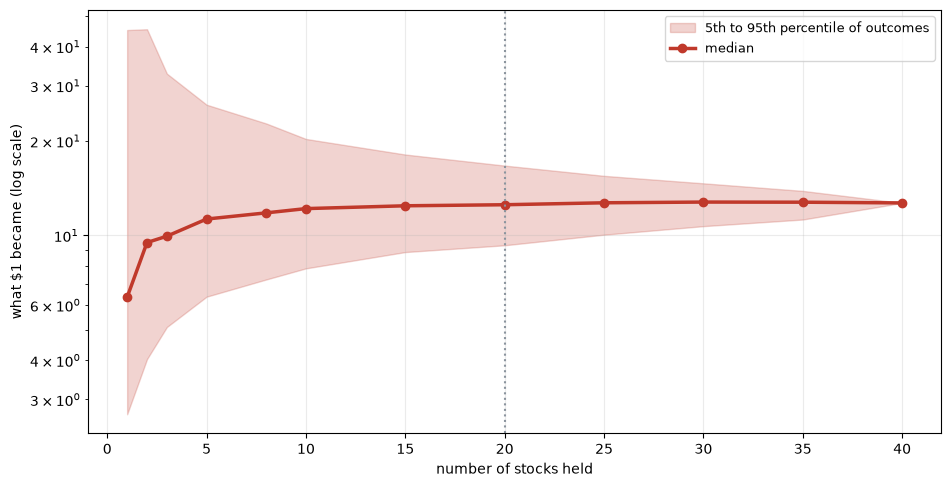

          median_wealth  p05_wealth  p95_wealth  ratio_95_05
n_stocks                                                    
1                6.3500      2.6900     45.1700      16.7900
2                9.4900      4.0300     45.4300      11.2600
3                9.9400      5.1100     32.8000       6.4200
5               11.2800      6.3800     26.1100       4.0900
8               11.8000      7.2400     22.7500       3.1400
10              12.1800      7.8500     20.3000       2.5900
15              12.4300      8.8500     18.1100       2.0500
20              12.5300      9.3000     16.7000       1.7900
25              12.7100     10.0500     15.4900       1.5400
30              12.7800     10.7000     14.6600       1.3700
35              12.7600     11.2400     13.8700       1.2300
40              12.7000     12.7000     12.7000       1.0000


In [4]:
wc = st.terminal_wealth_curve(R, n_draws=500)
fig, ax = plt.subplots(figsize=(11, 5.5))
ax.fill_between(wc.index, wc["p05_wealth"], wc["p95_wealth"], alpha=0.22,
                color="#c0392b", label="5th to 95th percentile of outcomes")
ax.plot(wc.index, wc["median_wealth"], "o-", lw=2.5, color="#c0392b", label="median")
ax.axvline(20, color="#8b949e", ls=":", lw=1.5)
ax.set_yscale("log")
ax.set_xlabel("number of stocks held")
ax.set_ylabel("what $1 became (log scale)"); ax.legend(fontsize=9)
plt.show()
print(wc[["median_wealth", "p05_wealth", "p95_wealth", "ratio_95_05"]].round(2).to_string())

The red band is the gap between a lucky investor and an unlucky one who followed the *same
rule*. At twenty names it is still wide. It keeps narrowing long after the volatility chart
went flat.

## 3 · Both curves, one picture

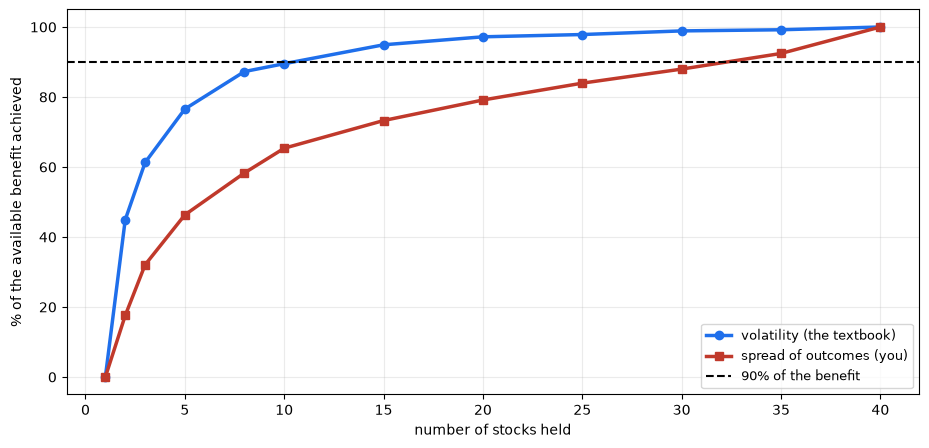

90% by volatility:        10 stocks
90% by spread of outcomes: 32 stocks


In [5]:
v = (vc["mean_vol"] - vc["mean_vol"].iloc[-1])
v = v / v.iloc[0]
w = (wc["log_sd"] - wc["log_sd"].iloc[-1])
w = w / w.iloc[0]
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(v.index, (1 - v) * 100, "o-", lw=2.5, color="#1f6feb",
        label="volatility (the textbook)")
ax.plot(w.index, (1 - w) * 100, "s-", lw=2.5, color="#c0392b",
        label="spread of outcomes (you)")
ax.axhline(90, color="k", ls="--", lw=1.5, label="90% of the benefit")
ax.set_xlabel("number of stocks held")
ax.set_ylabel("% of the available benefit achieved"); ax.legend(fontsize=9)
plt.show()
print(f"90% by volatility:        {st.stocks_for_share(vc, 'mean_vol', 0.90):.0f} stocks")
print(f"90% by spread of outcomes: {st.stocks_for_share(wc, 'log_sd', 0.90):.0f} stocks")

## 4 · Why: most stocks do not matter

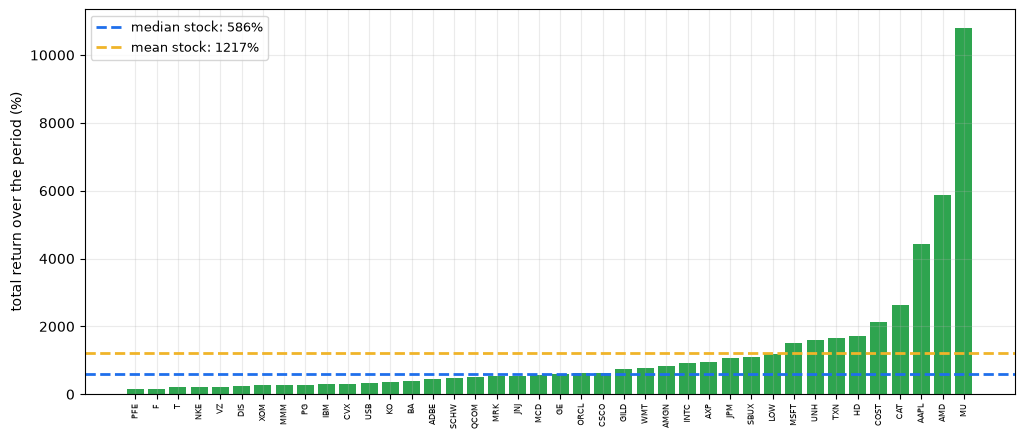

0% of these names lost money outright
the top 10% produced 49% of the basket's total return
median stock 586% vs mean 1217%


In [6]:
conc = st.concentration_of_returns(R)
total = (np.exp(np.log1p(R.dropna()).sum()) - 1).sort_values()
fig, ax = plt.subplots(figsize=(12, 5))
colors = ["#c0392b" if t < 0 else "#2ea44f" for t in total]
ax.bar(range(len(total)), total * 100, color=colors)
ax.axhline(total.median() * 100, color="#1f6feb", lw=2, ls="--",
           label=f"median stock: {total.median():.0%}")
ax.axhline(total.mean() * 100, color="#f0b429", lw=2, ls="--",
           label=f"mean stock: {total.mean():.0%}")
ax.set_xticks(range(len(total)))
ax.set_xticklabels(total.index, rotation=90, fontsize=6)
ax.set_ylabel("total return over the period (%)"); ax.legend(fontsize=9)
plt.show()
print(f"{conc['share_negative']:.0%} of these names lost money outright")
print(f"the top 10% produced {conc['share_from_top_10pct']:.0%} of the basket's total return")
print(f"median stock {conc['median_stock_return']:.0%} vs mean "
      f"{conc['mean_stock_return']:.0%}")

> \U0001F52C **For the quants.** This is Bessembinder (2018) inside one basket. Because the
> distribution is right-skewed, the *median* small portfolio does worse than the *mean* small
> portfolio — and the volatility curve, which averages across portfolios, cannot show it.

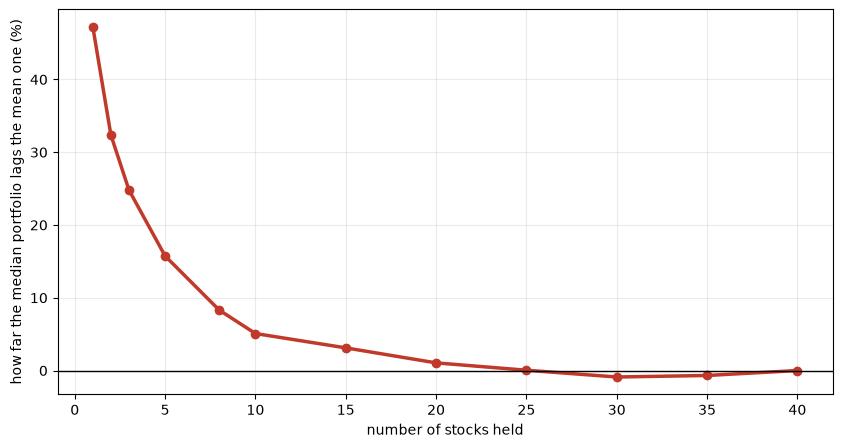

,median,mean,shortfall,share_below_mean
n_stocks,,,,
1,6.3532,12.0348,0.4721,0.7880
2,9.4923,14.0332,0.3236,0.7540
3,9.9448,13.2242,0.2480,0.6780
5,11.2795,13.3872,0.1574,0.6280
8,11.8019,12.8701,0.0830,0.5980
10,12.1771,12.8294,0.0508,0.5800
15,12.4312,12.8309,0.0311,0.5560
20,12.5269,12.6602,0.0105,0.5220
25,12.7076,12.7128,0.0004,0.5020


In [7]:
sk = st.skew_and_the_median_portfolio(R, n_draws=500)
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(sk.index, sk["shortfall"] * 100, "o-", lw=2.5, color="#c0392b")
ax.axhline(0, color="k", lw=1)
ax.set_xlabel("number of stocks held")
ax.set_ylabel("how far the median portfolio lags the mean one (%)")
plt.show()
sk.round(4)

## 5 · The verdict

**Signal: Confirmed.** The textbook curve is real. Across 40 large-cap names over 16 years, the average equal-weighted portfolio's volatility falls from 27.9% with one stock to 17.0% with all of them, and **10 holdings** capture 90% of that reduction. Evans and Archer's fifteen is the right answer to the question they asked, and anyone repeating it is not making an arithmetic error.

**Tradability: Useful.** They are answering the wrong question. Standard deviation describes the *average* portfolio; an investor holds *one*, for decades. Measured on the dispersion of terminal wealth across randomly drawn portfolios — what actually varies between one investor and another — 90% of the available benefit needs **32 holdings**, 3.1× the textbook number. With 10 stocks the 5th-to-95th percentile of outcomes still spans a factor of **2.6×**; reaching the textbook's implied comfort takes far more names. The mechanism is skew, not covariance: 0% of these names lost money outright over the period and the top decile produced 49% of the basket's total return, so a small portfolio probably misses the names that mattered. Its median terminal wealth sits 5% below the mean at 10 names and -1% below at 32. Volatility cannot see any of this, because averaging across draws is exactly the step that hides it.

## 6 · Going further \U0001F6AA

- **The practical answer is "an index fund"**, and this is why: it is not twenty names, it is
  all of them, which removes the outcome dispersion the textbook chart never measured.
- **If you do pick stocks, more is more** for longer than the textbook suggests. The
  counterweight is Statman's: costs and attention are real, and this study measures only the
  benefit side.
- **Ask which statistic any risk chart is plotting.** Volatility, tracking error and outcome
  dispersion answer different questions and flatten at different points. Most charts do not
  say which one they are.